# Data Structures, Functions, Control Flow, and Error Handling
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Before you can build analysis pipelines for EMG signals, organize trial metadata, or write reusable processing functions, you need to master Python's core data structures and control flow. This notebook covers tuples, lists, dictionaries, sets, slicing, loops, functions, comprehensions, generators, and error handling — the building blocks of every research script you'll write.

Every concept is illustrated with examples relevant to movement neuroscience wherever possible: storing participant metadata in dictionaries, iterating over trials with `enumerate`, filtering data with comprehensions, and handling file I/O errors gracefully.

**Prerequisites:** Python Basics (L0), Introduction to NumPy (L1).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---

## Table of Contents

**Part I — Data Structures**
1. [Quick Review — Introspection & Indentation](#1)
2. [Tuples — Immutable Sequences](#2)
3. [Lists — Mutable Sequences](#3)
4. [Slicing — Selecting Subsequences](#4)
5. [Dictionaries — Key-Value Stores](#5)
6. [Sets — Unique Collections](#6)

**Part II — Control Flow**
7. [Conditional Statements — `if`, `elif`, `else`](#7)
8. [Loops — `for` and `while`](#8)
9. [Built-In Sequence Functions — `enumerate`, `zip`, `sorted`](#9)
10. [Comprehensions — List, Set, and Dictionary](#10)

**Part III — Functions**
11. [Functions — `def`, Scope, and Multiple Returns](#11)
12. [`*args` and `**kwargs` — Flexible Function Arguments](#12)
13. [Docstrings and Type Hints — Writing Self-Documenting Code](#13)
14. [Recursive Functions](#14)
15. [Lambda Functions](#15)
16. [Generator Expressions](#16)

**Part IV — Error Handling and I/O**
17. [Error Handling — `try` / `except`](#17)
18. [File Input and Output](#18)

**Part V — Practice**
19. [Exercises](#19)
20. [Summary & Further Reading](#20)

In [1]:
# ---- Setup ----
import numpy as np

---
# Part I — Data Structures

## 1. Quick Review — Introspection & Indentation <a id='1'></a>

### Introspection with `?`

You can inspect any object by appending `?` to it. This shows its type, docstring, and other useful info.

In [2]:
# ---- Introspection: get info about an object ----

b = [1, 2, 3]
b?  # Shows type, length, and content (output appears in a panel below)

SyntaxError: invalid syntax (351554764.py, line 4)

### Indentation = Structure

Python uses **whitespace** (indentation) to define code blocks — not braces `{}` like C/Java or `end` statements like MATLAB. This means **your code won't run if the indentation is wrong**, but it also means properly-written Python is inherently readable.

- A **colon** (`:`) denotes the start of an indented block (after `if`, `for`, `while`, `def`, `class`).
- Standard indentation is **4 spaces** (not tabs). Colab and Jupyter handle this automatically.
- All lines in the same block must be indented to the **same level**.

In [3]:
# ---- Selection sort: demonstrating indentation levels ----
# Notice how indentation level determines which block each line belongs to.

arr = [5, 9, 1, 10, 3, 8, 4, 2, 7, 6]
print(f"Before sorting: {arr}")

max_size = len(arr)                              # Total number of elements
for i in range(0, max_size):                      # Outer loop: each position (level 1)
    for j in range(i + 1, len(arr)):              # Inner loop: compare with remaining (level 2)
        if arr[i] > arr[j]:                       # If current > later element (level 3)
            arr[i], arr[j] = arr[j], arr[i]       # Pythonic swap! (level 4)

print(f"After sorting:  {arr}")

Before sorting: [5, 9, 1, 10, 3, 8, 4, 2, 7, 6]
After sorting:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [4]:
# ---- Semicolons: multiple statements on one line (discouraged) ----

a = 5; b = 6; c = 7  # Legal, but prefer separate lines for readability

---
## 2. Tuples — Immutable Sequences <a id='2'></a>

A **tuple** is a fixed-length, **immutable** sequence. Once created, you cannot add, remove, or change its elements. Tuples use **parentheses** `()` (or just commas).

**Why use tuples?** They're safer than lists because they can't be accidentally modified — perfect for storing fixed data like `(x, y)` coordinates, `(participant_id, condition)` pairs, or function return values.

**Neuroscience use:** Store fixed trial metadata like `(trial_id, condition, target_angle)` that shouldn't be altered after creation.

In [5]:
# ---- Creating tuples ----
# Tuples can be created with parentheses, the tuple() constructor, or just commas.

tup = (4, 5, 6)                          # Parentheses (most common)
print(f"tup = {tup}")

tup2 = tuple([4, -9, 2])                 # Convert a list to a tuple
print(f"tup2 = {tup2}")

tup3 = tuple(['fox', [1, 2], True])      # Mixed types are OK
print(f"tup3 = {tup3}")
print(f"Type: {type(tup3)}")

tup = (4, 5, 6)
tup2 = (4, -9, 2)
tup3 = ('fox', [1, 2], True)


In [6]:
# ---- Tuples are IMMUTABLE ----
# Uncomment to see the error:
# tup[0] = 9  # TypeError: 'tuple' object does not support item assignment

In [7]:
# ---- BUT: mutable objects INSIDE a tuple CAN be modified ----
# The tuple itself doesn't change (still 3 elements), but the list inside it does.
# This is because the tuple stores a REFERENCE to the list, and the reference doesn't change.

tup = tuple(['foo', [1, 2], True])
tup[1].append(3)                          # Modify the list inside the tuple
print(f"Modified list inside tuple: {tup}")  # ('foo', [1, 2, 3], True)

('foo', [1, 2, 3], True)


In [8]:
# ---- Nested tuples and concatenation ----
# Tuples can contain other tuples (nesting) and be joined with + (concatenation).

nested_tup = (4, 5, 6), (7, 8)           # A tuple of two tuples
print(f"Nested: {nested_tup}")
print(f"Second element: {nested_tup[1]}")  # Access inner tuple

combined = (4, None, 'foo') + (6, 0) + ('bar',)  # Note: ('bar',) needs trailing comma!
print(f"Combined: {combined}")

Nested: ((4, 5, 6), (7, 8))
Combined: (4, None, 'foo', 6, 0, 'bar')


### Tuple Unpacking

Python can automatically **unpack** a tuple into separate variables. This is one of Python's most elegant features — you'll use it constantly with `enumerate()`, `zip()`, and function return values.

In [9]:
# ---- Basic and nested unpacking ----
# Python assigns each tuple element to a separate variable in one line.

tup = (4, 5, 6)
a, b, c = tup                             # Unpack 3 values into 3 variables
print(f"a={a}, b={b}, c={c}")

# Nested unpacking: works with tuples inside tuples
tup = 4, 5, (6, 7)
a, b, (c, d) = tup                        # Unpack the inner tuple too
print(f"a={a}, b={b}, c={c}, d={d}")

a=4, b=5, c=6
c=6, d=7


In [10]:
# ---- Pythonic variable swap using tuple unpacking ----
# In C or MATLAB you'd need a temp variable. In Python, one line:

a, b = 1, 2
print(f"Before: a={a}, b={b}")

b, a = a, b                               # Swap! No temp variable needed.
print(f"After:  a={a}, b={b}")

Before: a=1, b=2
After:  a=2, b=1


In [11]:
# ---- Star unpacking: capture the "rest" into a list ----
# The * collects all remaining elements into a list.

values = 1, 2, 3, 4, 5
a, b, *rest = values                      # a=1, b=2, rest=[3, 4, 5]
print(f"a={a}, b={b}, rest={rest}")

# Convention: use _ for variables you don't need
a, b, *_ = values                         # Discard the rest
print(f"a={a}, b={b} (rest discarded)")

a=1, b=2, rest=[3, 4, 5]
a=1, b=2


In [12]:
# ---- Tuple methods: .count() ----

a = (1, 2, 2, 2, 3, 4, 3, 2)
print(f"Count of 3: {a.count(3)}")
print(f"Count of 2: {a.count(2)}")

Count of 3: 2
Count of 2: 4


---
## 3. Lists — Mutable Sequences <a id='3'></a>

**Lists** are variable-length and **mutable** — you can add, remove, and modify elements after creation. Lists use **square brackets** `[]`.

Lists are the go-to data structure when you need to **accumulate results** (e.g., appending reaction times trial by trial) or when the data needs to be **reordered** (sorting, shuffling).

**Key performance note:** `.append()` is fast (O(1)). `.insert()` at the beginning is slow (O(n)) because every element must shift. Always prefer appending to inserting.

In [13]:
# ---- Creating and modifying lists ----
# Lists can hold any mix of types, including None.

a_list = [2, 3, 7, None]                  # Create with square brackets
tup = ("foo", "bar", "baz")
b_list = list(tup)                        # Convert tuple → list
print(f"b_list = {b_list}")

b_list[1] = "peekaboo"                    # Modify element at index 1
print(f"After modification: {b_list}")     # Lists are mutable!

b_list = ['foo', 'bar', 'baz']
After modification: ['foo', 'peekaboo', 'baz']


In [14]:
# ---- Adding elements: append, insert, extend ----
# append() is O(1) — fast. insert() is O(n) — slow for large lists.

b_list.append("dwarf")                    # Add to the END of the list
print(f"After append: {b_list}")

b_list.insert(1, "red")                   # Insert at index 1 (shifts everything right)
print(f"After insert at index 1: {b_list}")

After append: ['foo', 'peekaboo', 'baz', 'dwarf']
After insert: ['foo', 'red', 'peekaboo', 'baz', 'dwarf']


In [15]:
# ---- Removing elements: pop and remove ----
# pop(i) removes by INDEX and returns the removed element.
# remove(val) removes by VALUE (first occurrence only).

removed = b_list.pop(2)                   # Remove and return element at index 2
print(f"Popped '{removed}', list = {b_list}")

b_list.append("foo")                      # Add 'foo' so we can remove it
b_list.remove("foo")                      # Remove FIRST occurrence of 'foo'
print(f"After remove('foo'): {b_list}")

Popped 'peekaboo', list = ['foo', 'red', 'baz', 'dwarf']
After remove('foo'): ['red', 'baz', 'dwarf', 'foo']


In [16]:
# ---- Membership testing ----

print(f"'dwarf' in b_list: {'dwarf' in b_list}")
print(f"'dwarf' not in b_list: {'dwarf' not in b_list}")

'dwarf' in b_list: True
'dwarf' not in b_list: False


In [17]:
# ---- Concatenation (+) vs. extend ----

x = [4, None, "foo"] + [7, 8, (2, 3)]    # + creates a NEW list
print(f"Concatenated: {x}")

x.extend([9, 1, (4, 3)])                   # extend modifies IN PLACE (faster)
print(f"After extend: {x}")

Concatenated: [4, None, 'foo', 7, 8, (2, 3)]
After extend: [4, None, 'foo', 7, 8, (2, 3), 9, 1, (4, 3)]


In [18]:
# ---- Sorting ----
# .sort() modifies the list IN PLACE (returns None).
# For a non-destructive sort, use sorted() — covered in Section 9.3.

a = [7, 2, 5, 1, 3, 4]
a.sort()                                  # Sorts ascending, modifies 'a'
print(f"Sorted numbers: {a}")

# ---- Flattening a list of lists ----
# Very common when combining data from multiple trial blocks.

list_of_lists = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
everything = []
for chunk in list_of_lists:               # Loop over each sublist
    everything.extend(chunk)               # Add all elements from chunk
print(f"Flattened: {everything}")

Sorted: [1, 2, 3, 4, 5, 7]
Flattened: [1, 2, 3, 4, 5, 6, 7, 8, 9]


| Use **tuples** for... | Use **lists** for... |
|---|---|
| Data that shouldn't change (constants, coordinates) | Data you need to modify (append, remove, sort) |
| Function return values | Accumulating results in a loop |
| Dictionary keys (tuples are hashable) | Ordered collections you iterate over |

---
## 4. Slicing — Selecting Subsequences <a id='4'></a>

Slicing works on lists, tuples, strings, and NumPy arrays. The syntax is `sequence[start:stop:step]`.

**Critical rule:** The start index is **included**, the stop index is **excluded**. So `seq[2:5]` gives you elements at indices 2, 3, 4 — not 5.

**Negative indices** count from the end: `-1` is the last element, `-2` is second to last, etc.

In [19]:
# ---- Slicing examples ----
# Remember: start is INCLUDED, stop is EXCLUDED.

seq = [7, 2, 3, 7, 5, 6, 0, 1]

# You can also ASSIGN to a slice (replaces those elements)
seq[3:5] = [6, 3]                         # Replace indices 3 and 4
print(f"After seq[3:5] = [6,3]: {seq}")

# Omitting start or stop
print(f"seq[:5]    = {seq[:5]}")           # First 5 elements (indices 0-4)
print(f"seq[3:]    = {seq[3:]}")           # From index 3 to the end
print(f"seq[-4:]   = {seq[-4:]}")          # Last 4 elements
print(f"seq[-7:-2] = {seq[-7:-2]}")        # From 7th-to-last to 2nd-to-last

After seq[3:5] = [6,3]: [7, 2, 3, 6, 3, 6, 0, 1]
seq[:5]    = [7, 2, 3, 6, 3]
seq[3:]    = [6, 3, 6, 0, 1]
seq[-4:]   = [3, 6, 0, 1]
seq[-7:-2] = [2, 3, 6, 3, 6]


In [20]:
# ---- Step slicing ----

print(f"Every other: seq[::2]  = {seq[::2]}")
print(f"Reversed:    seq[::-1] = {seq[::-1]}")

Every other: seq[::2]  = [7, 3, 3, 0]
Reversed:    seq[::-1] = [1, 0, 6, 3, 6, 3, 2, 7]


---
## 5. Dictionaries — Key-Value Stores <a id='5'></a>

A **dictionary** (`dict`) stores **key-value pairs** using **curly braces** `{}`. It's arguably the most important data structure in Python.

Think of a dictionary as a lookup table: given a key (e.g., `"participant_id"`), it instantly returns the associated value (e.g., `"P01"`).

**Keys** must be immutable (strings, numbers, tuples). **Values** can be anything.

**Neuroscience use:** Store participant metadata (`{"id": "P01", "age": 24, "conditions": [...]}`), or map condition names to trial indices.

In [21]:
# ---- Creating and accessing ----

d1 = {"a": [2, 3, 4, 6, 1, 0], "b": [1, 2, 3, 4]}
print(f"d1['b'] = {d1['b']}")
print(f"'c' in d1: {'c' in d1}")

d1['b'] = [1, 2, 3, 4]
'c' in d1: False


In [22]:
# ---- Adding, modifying, deleting ----

d1[7] = "an integer"
d1["dummy"] = np.arange(5)
print(f"After adding: {d1}")

d1.pop("dummy")
del d1[7]
print(f"After cleanup: {d1}")

After adding: {'a': [2, 3, 4, 6, 1, 0], 'b': [1, 2, 3, 4], 7: 'an integer', 'dummy': array([0, 1, 2, 3, 4])}
After cleanup: {'a': [2, 3, 4, 6, 1, 0], 'b': [1, 2, 3, 4]}


In [23]:
# ---- Iterating and merging ----

print(f"Keys:   {list(d1.keys())}")
print(f"Values: {list(d1.values())}")
print(f"Items:  {list(d1.items())}")

d1.update({"b": "foo", "c": 12})
print(f"After update: {d1}")

Keys:   ['a', 'b']
Values: [[2, 3, 4, 6, 1, 0], [1, 2, 3, 4]]
Items:  [('a', [2, 3, 4, 6, 1, 0]), ('b', [1, 2, 3, 4])]
After update: {'a': [2, 3, 4, 6, 1, 0], 'b': 'foo', 'c': 12}


In [24]:
# ---- Practical example: group words by their first letter ----
# This pattern (building a dict of lists) is extremely common in data processing.
# In pandas, this is what .groupby() does under the hood.

words = ['apple', 'bat', 'bar', 'atom', 'book']
by_letter = {}                            # Empty dict to accumulate results

for word in words:
    letter = word[0]                       # Get the first character
    if letter not in by_letter:            # First time seeing this letter?
        by_letter[letter] = [word]         # Create a new list with this word
    else:
        by_letter[letter].append(word)     # Add to the existing list

print(f"Grouped: {by_letter}")

Grouped: {'a': ['apple', 'atom'], 'b': ['bat', 'bar', 'book']}


---
## 6. Sets — Unique Collections <a id='6'></a>

A **set** is an unordered collection of **unique** elements. Duplicates are automatically removed. Sets support mathematical set operations (union, intersection, difference).

**Neuroscience use:** Find which participants are in Study A but not Study B, get the unique set of conditions across all sessions, or check for duplicate trial IDs.

In [25]:
# ---- Sets: duplicates automatically removed ----

a = set([1, 2, 3, 3, 5, 9, 2, 4, 5])    # From a list (duplicates gone)
b = {2, 2, 2, 1, 3, 3, 3, 4, 5, 6, 7, 8} # Curly brace syntax
print(f"a = {a}")
print(f"b = {b}")

# ---- Set operations (like Venn diagrams) ----
print(f"Union (a | b):        {a.union(b)}")        # Elements in either set
print(f"Intersection (a & b): {a.intersection(b)}")  # Elements in BOTH sets
print(f"Difference (a - b):   {a - b}")             # Elements in a but NOT b

a = {1, 2, 3, 4, 5, 9}
b = {1, 2, 3, 4, 5, 6, 7, 8}
Union:        {1, 2, 3, 4, 5, 6, 7, 8, 9}
Intersection: {1, 2, 3, 4, 5}
Difference:   {9}


---
# Part II — Control Flow

## 7. Conditional Statements — `if`, `elif`, `else` <a id='7'></a>

Conditional statements let your code make decisions. Only the **first** matching branch executes — Python checks conditions top to bottom and stops at the first `True`.

**Neuroscience use:** Classify trials by outcome (`if error < 1: "accurate"`, `elif error < 3: "ok"`, `else: "miss"`), or route processing based on data type.

In [26]:
# ---- if / elif / else ----
# Python checks each condition top to bottom.
# The FIRST True condition executes; the rest are skipped.

a = 200
b = 33

if b > a:                                 # Check: is b greater than a?
    print("b is greater than a")
elif a == b:                              # Check: are they equal?
    print("a and b are equal")
else:                                     # None of the above were True
    print("a is greater than b")

# Chained comparisons — Python's elegant way to write range checks:
print(f"4 > 3 > 2 > 1 is {4 > 3 > 2 > 1}")  # True — all comparisons must hold

a is greater than b
4 > 3 > 2 > 1 is True


---
## 8. Loops — `for` and `while` <a id='8'></a>

Because Python has rich data structures (lists, dicts, tuples), loops work more powerfully here than in many other languages. The `for` loop iterates **directly over elements**, not indices.

**Key control statements inside loops:**
- `break` — exit the loop entirely
- `continue` — skip the rest of the current iteration and move to the next one

**Neuroscience use:** Process each trial in a list, iterate over participants, or loop until a convergence criterion is met.

In [27]:
# ---- for loop: iterate directly over elements ----

fruits = ["apple", "banana", "cherry"]
for x in fruits:
    print(x)

apple
banana
cherry


In [28]:
# ---- range() for numeric iteration ----

print("range(6):")
for x in range(6):
    print(x, end=" ")

print("\n\nrange(2, 30, 3):")
for x in range(2, 30, 3):
    print(x, end=" ")

range(6):
0 1 2 3 4 5 

range(2, 30, 3):
2 5 8 11 14 17 20 23 26 29 

In [29]:
# ---- break and continue ----
# break: exits the INNERMOST loop entirely.
# continue: skips the rest of the current iteration, goes to next.

fruits = ["apple", "banana", "cherry"]
for i in range(2):                        # Outer loop: runs twice (i=0, i=1)
    for x in fruits:                      # Inner loop: iterates over fruits
        if x == "banana":
            break                         # Exit inner loop when we hit banana
        print(f"  i={i}, fruit={x}")      # Only prints apple (before banana)

  i=0, fruit=apple
  i=1, fruit=apple


In [30]:
# ---- Nested loops ----

adj = ["red", "big", "tasty"]
fruits = ["apple", "banana", "cherry"]
for x in adj:
    for y in fruits:
        print(f"{x} {y}")

red apple
red banana
red cherry
big apple
big banana
big cherry
tasty apple
tasty banana
tasty cherry


In [31]:
# ---- while loop with continue ----
# A while loop runs as long as its condition is True.
# 'continue' skips the rest of the current iteration.

i = 0
while i < 6:                              # Keep looping while i < 6
    i += 1                                # Increment FIRST (avoid infinite loop!)
    if i == 3:
        continue                          # Skip printing when i == 3
    print(i, end=" ")                     # Prints: 1 2 4 5 6
print()                                   # Newline at the end

1 2 4 5 6 


---
## 9. Built-In Sequence Functions — `enumerate`, `zip`, `sorted` <a id='9'></a>

These three functions are workhorses you'll use in almost every script.

### 9.1 `enumerate` — Loop with an Index Counter

In [32]:
# ---- enumerate: get (index, value) pairs ----

browsers = ['Chrome', 'Firefox', 'Opera', 'Vivaldi']
print(list(enumerate(browsers)))

[(0, 'Chrome'), (1, 'Firefox'), (2, 'Opera'), (3, 'Vivaldi')]


In [33]:
# ---- enumerate in a for loop ----

fruits = ["Apple", "Berry", "Cherry"]
for i, fruit in enumerate(fruits):
    print(f"Trial {i}: {fruit}")

Trial 0: Apple
Trial 1: Berry
Trial 2: Cherry


In [34]:
# ---- enumerate with custom start ----

for i, letter in enumerate("Apple", start=1):
    print(f"Position {i}: '{letter}'")

Position 1: 'A'
Position 2: 'p'
Position 3: 'p'
Position 4: 'l'
Position 5: 'e'


In [35]:
# ---- Iterating over dictionaries (.items(), no enumerate needed) ----

d = {'a': 1, 'b': 2, 'c': 3}
for key, value in d.items():
    print(f"key='{key}', value={value}")

key='a', value=1
key='b', value=2
key='c', value=3


### 9.2 `zip` — Parallel Iteration

`zip()` takes two or more iterables and yields tuples of corresponding elements. It stops at the **shortest** iterable.

This is one of the most useful functions in Python — any time you have **parallel lists** that belong together (participant IDs + their data, time stamps + measurements), `zip` is how you iterate over them together.

**Neuroscience use:** Iterate over time and position arrays simultaneously, pair participant IDs with their data, or combine conditions with trial numbers.

In [36]:
# ---- zip: iterate over multiple sequences in parallel ----
# zip pairs up corresponding elements from each list.
# It stops at the SHORTEST list.

participants = ["P01", "P02", "P03"]      # List 1: participant IDs
mean_rts = [0.312, 0.398, 0.287]          # List 2: their reaction times
ages = [24, 31, 27]                       # List 3: their ages

# zip gives us (P01, 0.312, 24), (P02, 0.398, 31), (P03, 0.287, 27)
for pid, rt, age in zip(participants, mean_rts, ages):
    print(f"{pid}: age={age}, mean RT={rt:.3f}s")

P01: age=24, mean RT=0.312s
P02: age=31, mean RT=0.398s
P03: age=27, mean RT=0.287s


In [37]:
# ---- zip to create a dictionary from two lists ----
# This is extremely common in data processing.

keys = ["participant", "condition", "rt"]
values = ["P01", "control", 0.312]

trial_dict = dict(zip(keys, values))
print(f"Dict from zip: {trial_dict}")

Dict from zip: {'participant': 'P01', 'condition': 'control', 'rt': 0.312}


In [38]:
# ---- zip with enumerate: index + parallel data ----

conditions = ["baseline", "rotation", "washout"]
n_trials = [20, 40, 20]

for i, (cond, n) in enumerate(zip(conditions, n_trials)):
    print(f"Block {i}: {cond} ({n} trials)")

Block 0: baseline (20 trials)
Block 1: rotation (40 trials)
Block 2: washout (20 trials)


In [39]:
# ---- "Unzipping" with zip(*...) ----
# Transpose a list of tuples into separate lists.

pairs = [("P01", 0.31), ("P02", 0.38), ("P03", 0.29)]
pids, rts = zip(*pairs)   # Unzip
print(f"PIDs: {pids}")
print(f"RTs:  {rts}")

PIDs: ('P01', 'P02', 'P03')
RTs:  (0.31, 0.38, 0.29)


### 9.3 `sorted` vs `.sort()` — Sorting Without Side Effects

| Function | Modifies original? | Returns |
|---|---|---|
| `list.sort()` | **Yes** (in place) | `None` |
| `sorted(iterable)` | **No** (creates new) | New sorted list |

Use `sorted()` when you need to keep the original order intact (e.g., for plotting raw data alongside sorted data).

In [40]:
# ---- .sort() modifies the list IN PLACE (returns None!) ----

original = [7, 2, 5, 1, 3, 4]
result = original.sort()     # WARNING: result is None!
print(f"original after .sort(): {original}")
print(f"result = {result}")  # None — a common gotcha

original after .sort(): [1, 2, 3, 4, 5, 7]
result = None


In [41]:
# ---- sorted() returns a NEW list, original unchanged ----

original = [7, 2, 5, 1, 3, 4]
sorted_copy = sorted(original)

print(f"original:    {original}")      # Still [7, 2, 5, 1, 3, 4]
print(f"sorted_copy: {sorted_copy}")   # [1, 2, 3, 4, 5, 7]

original:    [7, 2, 5, 1, 3, 4]
sorted_copy: [1, 2, 3, 4, 5, 7]


In [42]:
# ---- sorted() works on ANY iterable (tuples, strings, generators) ----

print(f"Sorted string: {sorted('python')}")
print(f"Sorted tuple:  {sorted((3, 1, 4, 1, 5))}")

# Sort with a key function (like lambda):
words = ["cherry", "apple", "banana"]
print(f"By length: {sorted(words, key=len)}")

# Reverse sort:
print(f"Descending: {sorted([3, 1, 4, 1, 5], reverse=True)}")

Sorted string: ['h', 'n', 'o', 'p', 't', 'y']
Sorted tuple:  [1, 1, 3, 4, 5]
By length: ['apple', 'cherry', 'banana']
Descending: [5, 4, 3, 1, 1]


In [43]:
# ---- Practical: sort trials by reaction time ----

trial_data = [("P01", 0.342), ("P02", 0.298), ("P03", 0.315), ("P04", 0.287)]

# Sort by RT (second element of each tuple):
fastest_first = sorted(trial_data, key=lambda x: x[1])
print("Fastest to slowest:")
for pid, rt in fastest_first:
    print(f"  {pid}: {rt:.3f}s")

Fastest to slowest:
  P04: 0.287s
  P02: 0.298s
  P03: 0.315s
  P01: 0.342s


---
## 10. Comprehensions — List, Set, and Dictionary <a id='10'></a>

```python
new_list = [expression for value in collection if condition]
new_set  = {expression for value in collection if condition}
new_dict = {key_expr: val_expr for value in collection if condition}
```

In [44]:
# ---- Dictionary comprehension ----

strings = ["a", "as", "batssssss", "car", "dove", "python"]
loc_mapping = {value: index for index, value in enumerate(strings)}
print(f"Location mapping: {loc_mapping}")

Location mapping: {'a': 0, 'as': 1, 'batssssss': 2, 'car': 3, 'dove': 4, 'python': 5}


In [45]:
# ---- Nested list comprehension: flatten ----

some_tuples = [(1, 2, 3), (4, 5, 6), (7, 8, 9)]
flattened = [x for tup in some_tuples for x in tup]
print(f"Flattened: {flattened}")

# List of lists:
result = [[x for x in tup] for tup in some_tuples]
print(f"List of lists: {result}")

Flattened: [1, 2, 3, 4, 5, 6, 7, 8, 9]
List of lists: [[1, 2, 3], [4, 5, 6], [7, 8, 9]]


---
# Part III — Functions

## 11. Functions — `def`, Scope, and Multiple Returns <a id='11'></a>

Functions are the primary method of **code organization and reuse** in Python. A well-written function does one thing, has a clear name, takes inputs as parameters, and returns a result.

Python functions support:
- **Positional arguments** — passed by position: `f(3, 4)`
- **Keyword arguments** — passed by name: `f(x=3, y=4)`
- **Default values** — optional parameters: `def f(x, y=10)`
- **Multiple return values** — via tuple unpacking

**Neuroscience use:** Write reusable functions for computing reaction times, filtering signals, or batch-processing participant data.

In [46]:
# ---- Function with positional and keyword (default) arguments ----
# 'x' and 'y' are positional (required).
# 'z' has a default value of 1.5 (optional).

def my_function(x, y, z=1.5):
    """Demonstrate positional and keyword arguments."""
    if z > 1:
        return z * (x + y)                # Multiply if z is large
    else:
        return z / (x + y)                # Divide if z is small

# Call with positional args only (z uses its default of 1.5):
print(f"my_function(3, 4) = {my_function(3, 4)}")

# Call with z explicitly set:
print(f"my_function(3, 4, 0.5) = {my_function(3, 4, 0.5)}")

my_function(3, 4, 0.5) = 0.07142857142857142
my_function(3.14, 7, 3.5) = 35.49


In [47]:
# ---- Returning multiple values ----
# Python functions can return multiple values as a tuple.
# This is the standard pattern — you'll see it everywhere.

def compute_stats():
    """Return three computed values as a tuple."""
    a = 5
    b = 6 * 2
    c = 7
    return a, b, c                        # Returns the tuple (5, 12, 7)

# Unpack the returned tuple into separate variables:
x, y, z = compute_stats()
print(f"x={x}, y={y}, z={z}")

# Alternative: return a dictionary for named results
def compute_stats_dict():
    """Return results as a labeled dictionary."""
    return {"mean": 5, "std": 6, "n": 7}

result = compute_stats_dict()
print(f"Dict result: {result}")
print(f"Access by name: result['mean'] = {result['mean']}")

x=5, y=12, z=7
Dict result: {'mean': 5, 'std': 6, 'n': 7}


### Namespaces and Scope

Variables created **inside** a function are **local** — they only exist during the function call and are destroyed afterward. But functions **can** read (and even modify) variables from the outer scope.

Understanding scope prevents one of the most common bugs in research code: accidentally modifying a global variable inside a function.

In [48]:
# ---- Local scope: 'a' is created and destroyed inside the function ----
# Variables defined inside a function do NOT exist outside it.

def func_local():
    a = []                                # 'a' is LOCAL to this function
    for i in range(5):
        a.append(i)                       # Modifying the local 'a'
    print(f"Inside func_local: a = {a}")

func_local()
# print(a)  # NameError! 'a' doesn't exist out here.

Inside func_local: a = [0, 1, 2, 3, 4]


In [49]:
# ---- Outer scope: function modifies a variable from the enclosing scope ----
# WARNING: This pattern can cause subtle bugs! The function changes 'a' every time.

a = []                                    # 'a' defined in the OUTER scope

def func_outer():
    for i in range(5):
        a.append(i)                       # Modifying the OUTER 'a'!

func_outer()                              # First call: a = [0, 1, 2, 3, 4]
print(f"After first call:  a = {a}")

func_outer()                              # Second call: appends MORE to the same 'a'
print(f"After second call: a = {a}")      # a = [0,1,2,3,4, 0,1,2,3,4]

After first call:  a = [0, 1, 2, 3, 4]
After second call: a = [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]


**Best practice:** Avoid modifying outer-scope variables inside functions. Pass data as arguments and return results.

---
## 12. `*args` and `**kwargs` — Flexible Function Arguments <a id='12'></a>

Sometimes you need a function that accepts a **variable number** of arguments. Python provides two mechanisms:

| Syntax | Collects | As type | Example call |
|---|---|---|---|
| `*args` | Extra **positional** arguments | `tuple` | `f(1, 2, 3)` |
| `**kwargs` | Extra **keyword** arguments | `dict` | `f(color='red', lw=2)` |

**Why this matters:** You'll encounter `*args` and `**kwargs` everywhere in scientific Python. Every time you call `plt.plot(x, y, color='red', linewidth=2)`, those keyword arguments are collected as `**kwargs` inside Matplotlib's code.

**Neuroscience use:** Writing wrapper functions that pass plotting options through to Matplotlib, or analysis functions that accept variable numbers of signals.

In [50]:
# ---- *args: accept any number of positional arguments ----
# The * collects all extra positional arguments into a tuple called 'values'.

def compute_mean(*values):
    """Compute mean of any number of values."""
    print(f"  Received {len(values)} values: {values}")  # 'values' is a tuple
    return sum(values) / len(values)       # Compute and return the mean

print(f"Mean of 3 values: {compute_mean(3, 7, 11)}")
print(f"Mean of 7 values: {compute_mean(1, 2, 3, 4, 5, 6, 7)}")

  Received 3 values: (3, 7, 11)
Mean: 7.0
  Received 7 values: (1, 2, 3, 4, 5, 6, 7)
Mean: 4.0


In [51]:
# ---- **kwargs: accept any number of keyword arguments ----
# The ** collects all extra keyword arguments into a dict called 'details'.

def print_participant_info(pid, **details):
    """Print participant info with arbitrary additional details."""
    print(f"Participant {pid}:")
    for key, value in details.items():     # 'details' is a dictionary
        print(f"  {key}: {value}")

# You can pass ANY keyword arguments — they all go into 'details':
print_participant_info("P01", age=24, handedness="right", injury="none")
print()
print_participant_info("P02", age=31, group="patient", medication="yes")

Participant P01:
  age: 24
  handedness: right
  injury: none

Participant P02:
  age: 31
  group: patient
  medication: yes


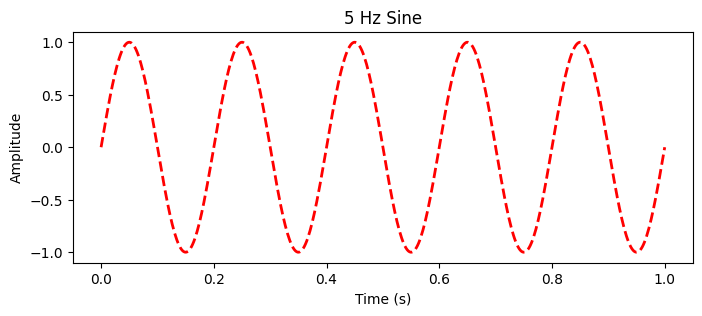

In [52]:
# ---- Practical: wrapper function that passes options through ----
# This pattern is VERY common when building research plotting utilities.
# **plot_kwargs captures ALL extra keyword arguments and passes them to plt.plot().

import matplotlib.pyplot as plt

def plot_signal(time, data, title="Signal", **plot_kwargs):
    """Plot a signal with customizable matplotlib options."""
    plt.figure(figsize=(8, 3))
    plt.plot(time, data, **plot_kwargs)    # Forward ALL kwargs to plt.plot()
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

# Generate a test signal
t = np.linspace(0, 1, 500)
sig = np.sin(2 * np.pi * 5 * t)

# The caller can pass ANY matplotlib keyword arguments:
plot_signal(t, sig, title="5 Hz Sine", color='red', linewidth=2, linestyle='--')

In [53]:
# ---- Combining regular arguments, *args, and **kwargs ----
# Order matters: regular args → *args → keyword args with defaults → **kwargs

def flexible_func(required_arg, *args, default_val=10, **kwargs):
    """Show how all argument types combine."""
    print(f"required: {required_arg}")     # Always needed
    print(f"*args:    {args}")              # Extra positional → tuple
    print(f"default:  {default_val}")       # Has a default, can be overridden
    print(f"**kwargs: {kwargs}")            # Extra keyword → dict

flexible_func("hello", 1, 2, 3, default_val=99, extra="bonus")

required: hello
*args:    (1, 2, 3)
default:  99
**kwargs: {'extra': 'bonus'}


---
## 13. Docstrings and Type Hints — Writing Self-Documenting Code <a id='13'></a>

As your research code grows, **documentation** becomes critical. Python provides two key tools:

### 13.1 Docstrings

A docstring is a string literal placed as the **first statement** in a function, class, or module. It's accessible via `help()` and `?` and is the standard way to document what your code does.

The most common format in scientific Python is the **NumPy/SciPy docstring style**:

In [54]:
# ---- Docstring: NumPy/SciPy style (the scientific Python standard) ----

def compute_reaction_time(onset_time, stimulus_time, min_rt=0.1):
    """
    Compute reaction time from stimulus and movement onset times.

    Parameters
    ----------
    onset_time : float
        Time of movement onset in seconds.
    stimulus_time : float
        Time of stimulus presentation in seconds.
    min_rt : float, optional
        Minimum valid reaction time in seconds. Default is 0.1.

    Returns
    -------
    float or None
        Reaction time in seconds, or None if RT is below min_rt
        (likely an anticipatory response).

    Examples
    --------
    >>> compute_reaction_time(1.45, 1.10)
    0.35
    >>> compute_reaction_time(1.15, 1.10)
    None
    """
    rt = onset_time - stimulus_time
    if rt < min_rt:
        return None  # Anticipatory response
    return rt

# Now help() and ? show useful documentation:
help(compute_reaction_time)

Help on function compute_reaction_time in module __main__:

compute_reaction_time(onset_time, stimulus_time, min_rt=0.1)
    Compute reaction time from stimulus and movement onset times.

    Parameters
    ----------
    onset_time : float
        Time of movement onset in seconds.
    stimulus_time : float
        Time of stimulus presentation in seconds.
    min_rt : float, optional
        Minimum valid reaction time in seconds. Default is 0.1.

    Returns
    -------
    float or None
        Reaction time in seconds, or None if RT is below min_rt
        (likely an anticipatory response).

    Examples
    --------
    >>> compute_reaction_time(1.45, 1.10)
    0.35
    >>> compute_reaction_time(1.15, 1.10)
    None



### 13.2 Type Hints

Type hints (Python 3.5+) annotate the **expected types** of function parameters and return values. They don't enforce types at runtime, but they:
- Make code self-documenting
- Enable IDE autocompletion and error checking
- Are used throughout libraries like scikit-learn, MNE-Python, and PyTorch

In [55]:
# ---- Type hints: annotate parameters and return types ----

from typing import List, Optional, Tuple, Dict

def compute_trial_stats(
    reaction_times: List[float],
    remove_outliers: bool = True,
    threshold_sd: float = 2.0
) -> Dict[str, float]:
    """
    Compute summary statistics for a list of reaction times.

    Parameters
    ----------
    reaction_times : List[float]
        Reaction times in seconds.
    remove_outliers : bool, optional
        Whether to remove outliers beyond threshold_sd. Default True.
    threshold_sd : float, optional
        Number of standard deviations for outlier removal. Default 2.0.

    Returns
    -------
    Dict[str, float]
        Dictionary with 'mean', 'std', 'n', and 'n_removed' keys.
    """
    rts = np.array(reaction_times)
    n_original = len(rts)

    if remove_outliers:
        mean, std = rts.mean(), rts.std()
        mask = np.abs(rts - mean) < threshold_sd * std
        rts = rts[mask]

    return {
        "mean": float(rts.mean()),
        "std": float(rts.std()),
        "n": len(rts),
        "n_removed": n_original - len(rts)
    }

# Test it:
sample_rts = [0.31, 0.29, 0.34, 0.28, 0.92, 0.33, 0.30]  # 0.92 is an outlier
stats = compute_trial_stats(sample_rts)
print(f"Stats: {stats}")

Stats: {'mean': 0.30833333333333335, 'std': 0.021147629234082543, 'n': 6, 'n_removed': 1}


In [56]:
# ---- Common type hints you'll encounter ----

# Basic types:
# x: int, y: float, name: str, flag: bool

# Collections:
# data: List[float], pairs: Tuple[str, float], mapping: Dict[str, int]

# Optional (can be None):
# result: Optional[float]  means  float | None

# NumPy (informal but common):
# data: np.ndarray

# Example with Optional return:
def find_peak(data: np.ndarray, threshold: float = 0.5) -> Optional[int]:
    """Return index of first value above threshold, or None."""
    above = np.where(data > threshold)[0]
    return int(above[0]) if len(above) > 0 else None

print(f"Peak at index: {find_peak(np.array([0.1, 0.3, 0.8, 0.6]))}")
print(f"No peak: {find_peak(np.array([0.1, 0.2, 0.3]))}")

Peak at index: 2
No peak: None


**Best practice:** Combine docstrings + type hints for maximum clarity. Your collaborators (and your future self in 6 months) will thank you.

---
## 14. Recursive Functions <a id='14'></a>

In [57]:
# ---- Factorial: n! = n × (n-1) × ... × 1 ----
# Classic example of recursion: the function calls ITSELF with a smaller input.

def factorial(n):
    """Compute n! recursively."""
    if n == 0:                             # Base case: 0! = 1 (stops the recursion)
        return 1
    else:
        return n * factorial(n - 1)        # Recursive case: n! = n × (n-1)!

# Trace: factorial(5) → 5 × factorial(4) → 5 × 4 × factorial(3) → ... → 5×4×3×2×1
print(f"5! = {factorial(5)}")

5! = 120


In [58]:
# ---- Triangular recursion: sum of 1 + 2 + ... + k ----
# Another simple recursion example.

def tri_recursion(k):
    """Recursively compute 1 + 2 + ... + k."""
    if k > 0:                              # Recursive case
        return k + tri_recursion(k - 1)    # Add k to the sum of 1...(k-1)
    else:
        return 0                           # Base case: sum of nothing is 0

print(f"tri_recursion(6) = {tri_recursion(6)}")  # 1+2+3+4+5+6 = 21

tri_recursion(6) = 21


---
## 15. Lambda Functions <a id='15'></a>

**Lambda functions** are anonymous, one-line functions. They're useful for short operations, especially as arguments to `sorted()`, `map()`, and Pandas `.apply()`.

```python
# Regular function:
def double(x): return x * 2

# Equivalent lambda:
double = lambda x: x * 2
```

**Rule of thumb:** If the function is more than one line or you need to use it more than once, write a regular `def` function instead.

In [59]:
# ---- Lambda basics ----
# A lambda is a one-line anonymous function.
# Syntax: lambda arguments: expression

equiv_anon = lambda x: x * 3              # Takes x, returns x*3
print(f"Lambda(3): {equiv_anon(3)}")

add_three = lambda a, b, c: a + b + c     # Multiple arguments
print(f"5 + 6 + 2 = {add_three(5, 6, 2)}")

Lambda: 9
5 + 6 + 2 = 13


In [60]:
# ---- Lambda with higher-order functions ----

ints = [4, 0, 1, 5, 6]

def apply_to_list(some_list, f):
    return [f(x) for x in some_list]

print(f"Doubled: {apply_to_list(ints, lambda x: x * 2)}")

Doubled: [8, 0, 2, 10, 12]


In [61]:
# ---- Lambda as a sort key ----

strings = ["foo", "card", "bar", "aaaa", "abab"]
strings.sort(key=lambda x: len(set(x)))
print(f"Sorted by unique letters: {strings}")

Sorted by unique letters: ['aaaa', 'foo', 'abab', 'bar', 'card']


---
## 16. Generator Expressions <a id='16'></a>

A **generator** is a lazy iterator — it produces values one at a time instead of building the entire collection in memory. This is critical when working with large datasets.

Generators use `yield` (in functions) or parentheses `()` (in expressions), compared to lists which use `return` and `[]`.

**Neuroscience use:** Processing large EMG recordings file by file without loading all of them into memory at once.

In [62]:
# ---- Iterating over a dictionary yields its KEYS ----
# To get both keys and values, use .items()

some_dict = {"a": 1, "b": 2, "c": 3}
for key in some_dict:                     # Loops over KEYS only
    print(key, end=" ")
print()

# You can also create an iterator explicitly:
dict_iterator = iter(some_dict)
print(f"Iterator to list: {list(dict_iterator)}")

a b c 
Iterator to list: ['a', 'b', 'c']


In [63]:
# ---- Generator function with yield ----
# 'yield' produces one value at a time (lazy evaluation).
# The function pauses at each yield and resumes when the next value is requested.

def squares(n=10):
    """Generate squares from 1² to n² lazily."""
    print(f"Generating squares from 1 to {n ** 2}")
    for i in range(1, n + 1):
        yield i ** 2                       # Produce one value, then pause

gen = squares()                           # Creates the generator (nothing runs yet!)
print(f"Generator object: {gen}")

# Values are generated one at a time as we loop:
for val in gen:
    print(val, end=" ")

Generator object: <generator object squares at 0x79fe64273140>
Generating squares from 1 to 100
1 4 9 16 25 36 49 64 81 100 

In [64]:
# ---- Generator expression: compact syntax ----
# Looks like a list comprehension but with () instead of [].
# It does NOT build the full list in memory — produces values lazily.

gen_expr = (x ** 2 for x in range(100))   # () = generator, [] would be a list
print(f"Sum of squares 0-99: {sum(gen_expr)}")

# Generator inside dict():
squares_dict = dict((i, i ** 2) for i in range(5))
print(f"Squares dict: {squares_dict}")

Sum of squares 0-99: 328350
Squares dict: {0: 0, 1: 1, 2: 4, 3: 9, 4: 16}


---
# Part IV — Error Handling and I/O

## 17. Error Handling — `try` / `except` <a id='17'></a>

| Error | Cause | Example |
|---|---|---|
| `SyntaxError` | Invalid syntax | `while True print('hi')` |
| `TypeError` | Wrong type | `'2' + 2` |
| `ValueError` | Right type, wrong value | `float('something')` |
| `IndexError` | Index out of range | `[1,2,3][5]` |
| `KeyError` | Dict key not found | `d['missing']` |
| `FileNotFoundError` | File doesn't exist | `open('nope.csv')` |

In [65]:
# ---- Common errors (uncomment to see) ----

# while True print('Hello')  # SyntaxError
# '2' + 2                    # TypeError
# float("something")         # ValueError

In [66]:
# ---- try / except: handle errors gracefully ----
# Instead of crashing, catch the error and do something sensible.

def attempt_float(x):
    """Try to convert x to a float; return x unchanged if it fails."""
    try:
        return float(x)                    # Attempt the conversion
    except ValueError:                     # Catch only ValueError (not all errors)
        return x                           # Return the original if conversion fails

print(f"attempt_float('1.2345')    = {attempt_float('1.2345')}")    # Works: 1.2345
print(f"attempt_float('something') = {attempt_float('something')}")  # Fails gracefully

attempt_float('1.2345')   = 1.2345
attempt_float('something') = something


In [67]:
# ---- Handling multiple exception types ----
# You can catch different errors and handle each one differently.

try:
    value = int("abc")                     # This will raise a ValueError
except ValueError:
    print("ValueError: Invalid input. Please enter a number.")
except ZeroDivisionError:
    print("ZeroDivisionError: Cannot divide by zero.")
except Exception as e:                    # Catch-all for any other error
    print(f"Unexpected error: {e}")

Invalid input. Please enter a number.


---
## 18. File Input and Output <a id='18'></a>

We'll cover file I/O in detail with Pandas (L4). For now, here's a quick way to load CSV data with NumPy in Google Colab.

**Note:** If you're not using Colab, skip the `drive.mount()` step and use a local file path instead.

In [68]:
# ---- Load a CSV file with NumPy (Colab-specific) ----

import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks KINES 597/data/')
!pwd
data = np.loadtxt('GazeVar50.csv', delimiter=',', skiprows=1)
print(f"Shape: {data.shape}")
print(data[:3])

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks KINES 597/data
Shape: (45, 3)
[[ 38.06600189  14.39631433 289.36845925]
 [ 38.08599854  13.91540134 287.13510904]
 [ 38.10599899  13.96763103 284.29809017]]


---
# Part V — Practice

## 19. Exercises <a id='19'></a>

---

### Exercise 1: Participant Metadata Dictionary

Create a dictionary called `participant` with keys `"id"`, `"age"`, `"handedness"`, `"conditions"`. Then:
1. Add a new key `"n_trials"` with value `150`.
2. Print all keys.
3. Loop over `"conditions"` with `enumerate`.

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 2: `zip` for Parallel Data

Given:
```python
trial_ids = [1, 2, 3, 4, 5]
conditions = ["ctrl", "pert", "ctrl", "pert", "wash"]
rts = [0.31, 0.42, 0.29, 0.45, 0.35]
```

1. Use `zip` to iterate and print each trial as: `"Trial 1: ctrl, RT=0.310s"`.
2. Use `zip` to create a list of dictionaries, one per trial.
3. Use `sorted` with a `lambda` key to sort the dicts by RT (fastest first).

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 3: Write a Documented Analysis Function

Write a function `filter_rts` that:
1. Takes a list of reaction times and a `min_rt` / `max_rt` threshold.
2. Returns only the RTs within the valid range.
3. Has a complete **NumPy-style docstring** with Parameters, Returns, and Examples sections.
4. Uses **type hints** on all parameters and the return value.

In [ ]:
# ---- YOUR CODE HERE ----

# def filter_rts(rts: List[float], min_rt: float = 0.1, max_rt: float = 1.0) -> List[float]:
#     """
#     ...
#     """
#     pass

### Exercise 4: Flexible Plotting Function with `**kwargs`

Write a function `plot_trials(time, *signals, **plot_kwargs)` that:
1. Accepts a time array and any number of signal arrays via `*signals`.
2. Plots each signal on the same axes.
3. Passes `**plot_kwargs` through to `plt.plot()` so the caller can customize color, linewidth, etc.

In [ ]:
# ---- YOUR CODE HERE ----

# def plot_trials(time, *signals, **plot_kwargs):
#     ...
#
# t = np.linspace(0, 1, 100)
# s1 = np.sin(2*np.pi*3*t)
# s2 = np.sin(2*np.pi*5*t)
# plot_trials(t, s1, s2, color='blue', linewidth=0.8)

### Exercise 5: Safe File Loader (Challenge)

Write a function `safe_load(filepath)` with:
1. Full type hints (`filepath: str`) and return type (`Optional[np.ndarray]`).
2. A NumPy-style docstring.
3. `try/except` to catch `FileNotFoundError` and print a warning.
4. Returns the data if successful, or `None` if the file wasn't found.

In [ ]:
# ---- YOUR CODE HERE ----


---
## 20. Summary & Further Reading <a id='20'></a>

### What You Learned

| Concept | What it does | Example |
|---|---|---|
| **Tuples** `()` | Immutable sequences | `(4, 5, 6)`, `a, b, c = tup` |
| **Lists** `[]` | Mutable sequences | `.append()`, `.sort()`, `.extend()` |
| **Slicing** | Select subsequences | `seq[1:5]`, `seq[::-1]` |
| **Dicts** `{}` | Key-value stores | `{"name": "Alice", "age": 27}` |
| **Sets** | Unique elements | `set([1,2,2,3])` → `{1,2,3}` |
| **`if/elif/else`** | Conditional branching | Decision logic |
| **`for` / `while`** | Loops | `for x in data:` |
| **`break` / `continue`** | Control loop flow | Exit or skip iterations |
| **`enumerate`** | Loop with index | `for i, val in enumerate(data):` |
| **`zip`** | Parallel iteration | `for a, b in zip(list1, list2):` |
| **`sorted` vs `.sort()`** | Non-destructive vs in-place sort | `sorted(data, key=len)` |
| **Comprehensions** | Concise list/dict/set creation | `[x**2 for x in range(10)]` |
| **`def` functions** | Reusable code blocks | `def f(x, y=1): return x+y` |
| **`*args`** | Variable positional arguments | `def f(*values):` |
| **`**kwargs`** | Variable keyword arguments | `def f(**options):` |
| **Docstrings** | Inline documentation | NumPy-style Parameters/Returns |
| **Type hints** | Annotate expected types | `def f(x: float) -> int:` |
| **Recursion** | Function calls itself | `factorial(n)` |
| **`lambda`** | Anonymous one-line functions | `lambda x: x * 2` |
| **Generators** | Lazy iteration with `yield` | Memory-efficient for large data |
| **`try/except`** | Graceful error handling | Catch `FileNotFoundError` |

### Further Reading

- [Python Data Structures (Official Tutorial)](https://docs.python.org/3/tutorial/datastructures.html)
- [Python Errors and Exceptions](https://docs.python.org/3/tutorial/errors.html)
- [Real Python — *args and **kwargs](https://realpython.com/python-kwargs-and-args/)
- [Real Python — Type Hints](https://realpython.com/python-type-checking/)
- [NumPy Docstring Guide](https://numpydoc.readthedocs.io/en/latest/format.html) — the standard for scientific Python
- [PEP 8 Style Guide](https://peps.python.org/pep-0008/) — Python coding conventions

### What's Next?

With data structures, functions, and control flow mastered, you're ready for:
- **Pandas** — tabular data manipulation (trials, participants, metadata)
- **SciPy** — scientific computing (signal processing, statistics)
- **Object-Oriented Programming** — modeling experiments as classes

---

*Happy coding, and may your dictionaries be well-keyed and your loops never infinite!*